# SETUP

In [1]:
#config
import json
from pathlib import Path
import numpy as np
import pandas as pd
%load_ext autoreload
%autoreload 2
import sys

project_root = Path.cwd()
while not (project_root / "src" / "A_Config.py").exists():
    if project_root == project_root.parent:
        raise RuntimeError("couldn't find repo root (src/A_Config.py) above cwd")
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "src"))
from A_Config import (
    set_case, case_dir, source_dir, query_dir, sam3_masks_dir,
    frames_for_cam_poses_dir, frames_for_recon_dir, vggt_o_output_dir,
    predictions_path, ply_dir, reg_dir, csv_path_gps, csv_path_pose,
    assets_dir, recon_for_MAP_dir,recon_for_EVENT_dir, agent_p_output_dir,
    set_pass, pass_num, asset_name
)
from Eval_defs import importance_votes,consensus_spans, random_baseline_closed_form,random_baseline_blocks, load_labels,paper_edit_to_timegrid,score_paper_vs_GT_edits,labels_dir,cut_csv_to_timegrid, time_grid,spans_to_mask, annotator_beats_to_grid   # now resolvable
 


case_name =  "501_EGO_DANCE"
experiment = "Pipe_eval_02"
set_case(case_name, experiment)
paper_edit_json_path = agent_p_output_dir() / f"{case_name}_{experiment}_1_revision.json"
my_cut_csv = labels_dir() / f"{case_name}_cuts.csv"
BIN_S = 1.0      # vote grid, seconds. 0.1 matches the label precision if you want it finer
WEIGHTS = None   # or {"important": 1.0, "critical": 2.0}


# MY CUT
## VS machine

In [2]:
edges = time_grid(case_name, bin_s=BIN_S, labels=None, tol_s=1.0)
machine_paper_edit = paper_edit_to_timegrid(paper_edit_json_path, case_name, edges)
GT_edit = cut_csv_to_timegrid(my_cut_csv, edges)   # w, 0 or 1
#beta controls f_beta wihc controls soft f1
score_paper_vs_GT_edits(GT_edit, machine_paper_edit)
#f beta is precision and recall together. the F measure
#f-1 is beta =1 same calc but hard coded



501_EGO_DANCE: 2/6 beats have no resolved frames — skipped


{'soft_precision': 0.7573529411764706,
 'precision': 0.6323529411764706,
 'soft_recall': 0.6571428571428571,
 'recall': 0.6142857142857143,
 'soft_specificity': 0.7987804878048781,
 'specificity': 0.6951219512195121,
 'iou': 0.45263157894736844,
 'soft_f1': 0.7036982028813308,
 'f_beta': 0.6231884057971014,
 'beta': 1.0,
 'decay_s': 4.0,
 'true_p_s': 43.0,
 'false_p_s': 25.0,
 'false_n_s': 27.0,
 'true_n_s': 57.0,
 'edit_s': 68.0,
 'gt_s': 70.0,
 'len_ratio': 0.9714285714285714,
 'n_segments': 4,
 'shortest_seg_s': 9.0,
 'median_seg_s': 16.0}

# VS humans

[{'schema_version': 4, 'case_name': '501', 'category': 'EGO_EXO_4D', 'annotator': 'George', 'brief': 'Select the key moments of this recording i.e. the ones that together tell the main story of what is happening.', 'annotated_at': '2026-08-27T12:04:52.005Z', 'status': 'complete', 'video_duration_sec': 151.033333, 'time_spent_sec': 703, 'max_watched_sec': 151, 'overall': {'feelings': ['heartwarming'], 'pacing': 'about_right'}, 'subjects': [{'id': 'smtbgsaho_1', 'category': 'object', 'name': 'camera glasses', 'descriptor': 'main "character" wears and appears to be recording with black camera glasses', 'label': 'camera glasses'}, {'id': 'smtbgxrv3_3', 'category': 'object', 'name': 'cameras on tripods', 'descriptor': '4 cameras surround the area where two people are dancing', 'label': 'cameras on tripods'}, {'id': 'smtbh15t5_7', 'category': 'person', 'name': 'people', 'descriptor': "4 people are present on the video, with 3 clearlyh visible and one who's POV we're observing", 'label': 'peo

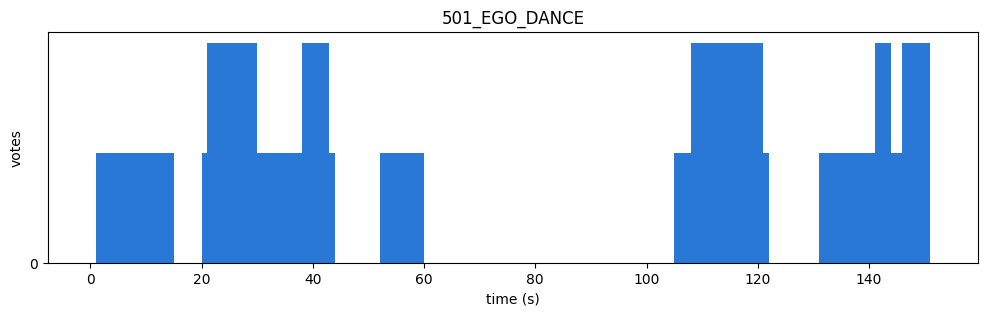

In [3]:
import matplotlib.pyplot as plt
vote_curve, majority_spans, rows = {}, {}, []

labels = load_labels()
print(labels)
edges, votes = importance_votes(labels, weights=WEIGHTS)
n_ann = len(labels)
vote_curve = (edges, votes)
majority_spans = consensus_spans(edges, votes, n_ann / 2 + 1e-9)
rows.append(dict(
    case=case_name,
    annotators=n_ann,
    names="/".join(sorted(l["annotator"] for l in labels)),
    dur_s=edges[-1],
    any_s=float((votes >= 1).sum() * BIN_S),
    majority_s=float((votes > n_ann / 2).sum() * BIN_S),
    unanimous_s=float((votes == n_ann).sum() * BIN_S),
    n_spans=len(majority_spans),
    ))

import matplotlib.pyplot as plt
edges, votes = vote_curve

fig, ax = plt.subplots(figsize=(12, 3))
ax.stairs(votes, edges, fill=True, color="#2a78d6")
ax.set_xlabel("time (s)")
ax.set_ylabel("votes")
ax.set_yticks(range(int(votes.max()) + 1))
ax.set_title(case_name)
plt.show()

saved /workspace/project/writing/Figures/sys_eval/501_EGO_DANCE_edit_overlaps.pdf


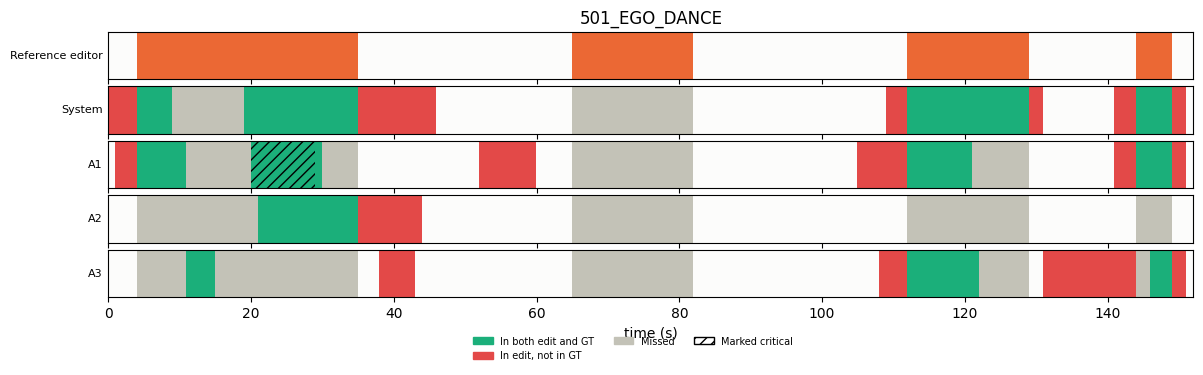

In [4]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from Eval_defs import timeline_agreement
TP_C, FP_C, FN_C, REF_C = "#1baf7a", "#e34948", "#c3c2b7", "#eb6834"


import matplotlib.pyplot as plt
from matplotlib.patches import Patch

tracks = {"ME (GT)": GT_edit, "machine": machine_paper_edit}
for l in load_labels():
    tracks[l["annotator"]] = annotator_beats_to_grid(l, edges)
timeline_agreement(case_name, edges, tracks, GT_edit=GT_edit, fname = f"{asset_name()}_edit_overlaps.pdf" )


In [5]:
decay_s=4
rows = [dict(editor="ME (GT)", time_min=70.0,
             **score_paper_vs_GT_edits(GT_edit, GT_edit, decay_s=decay_s))]

rows.append(dict(editor="machine", time_min=np.nan,
                 **score_paper_vs_GT_edits(GT_edit, machine_paper_edit, decay_s=decay_s)))

for l in load_labels():
    rows.append(dict(editor=l["annotator"],
                     time_min=round(l["time_spent_sec"] / 60, 1),
                     **score_paper_vs_GT_edits(GT_edit, annotator_beats_to_grid(l, edges), decay_s=decay_s)))
rand_row, null_stats, density = random_baseline_blocks(GT_edit, machine_paper_edit)
rows.append(rand_row)
rows.append(dict(editor="whole clip", time_min=np.nan,
                 **score_paper_vs_GT_edits(GT_edit, np.ones_like(GT_edit), decay_s=decay_s)))
comp = pd.DataFrame(rows)
comp[["editor", "edit_s" , "soft_f1",
      "soft_specificity", "specificity",
      "soft_precision", "precision",
      "soft_recall", "recall",
      "iou", "len_ratio", "n_segments", "median_seg_s","time_min" ]].round(3)



,editor,edit_s,soft_f1,soft_specificity,specificity,soft_precision,precision,soft_recall,recall,iou,len_ratio,n_segments,median_seg_s,time_min
0,ME (GT),70.0,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,4.00,17.00,70.0
1,machine,68.0,0.704,0.799,0.695,0.757,0.632,0.657,0.614,0.453,0.971,4.00,16.00,NaN
2,George,54.0,0.595,0.790,0.720,0.681,0.574,0.529,0.443,0.333,0.771,5.00,10.00,11.7
3,Tamara,23.0,0.333,0.909,0.890,0.674,0.609,0.221,0.200,0.177,0.329,1.00,23.00,10.4
4,Vuk,41.0,0.407,0.762,0.707,0.524,0.415,0.332,0.243,0.181,0.586,5.00,5.00,8.8
5,"random (blocks, n=200)",68.0,0.515,0.604,0.547,0.522,0.454,0.508,0.441,0.297,0.971,3.83,16.98,NaN
6,whole clip,152.0,0.701,0.146,0.000,0.539,0.461,1.000,1.000,0.461,2.171,1.00,152.00,NaN


In [6]:
null_stats

,Producer_agent_score,mean,p05,p95,pct
iou,0.453,0.297,0.140,0.469,92.0
soft_f1,0.704,0.515,0.317,0.709,94.0
precision,0.632,0.454,0.250,0.648,92.0
recall,0.614,0.441,0.243,0.629,92.0
specificity,0.695,0.547,0.378,0.708,92.0


saved /workspace/project/writing/Figures/sys_eval/501_EGO_DANCE_edit_overlaps.pdf


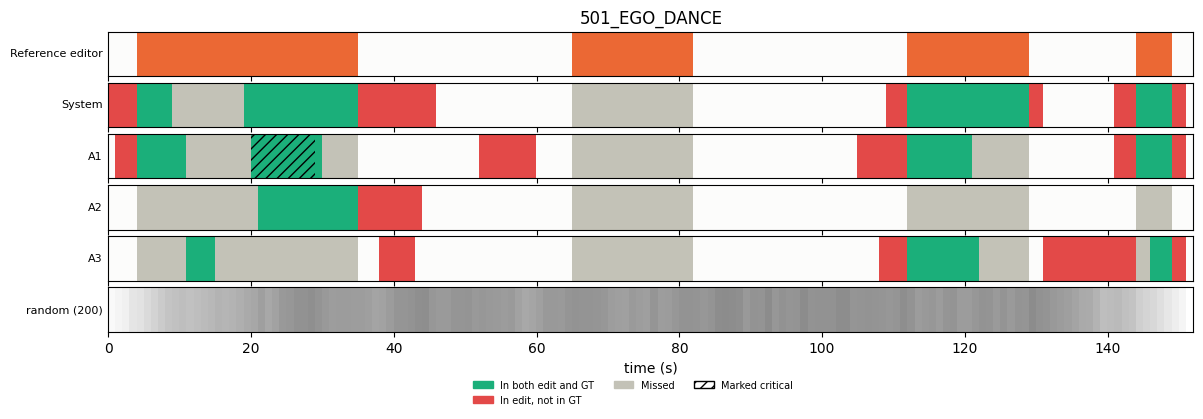

In [7]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from Eval_defs import timeline_agreement
TP_C, FP_C, FN_C, REF_C = "#1baf7a", "#e34948", "#c3c2b7", "#eb6834"


import matplotlib.pyplot as plt
from matplotlib.patches import Patch

tracks = {"ME (GT)": GT_edit, "machine": machine_paper_edit}
for l in load_labels():
    tracks[l["annotator"]] = annotator_beats_to_grid(l, edges)
tracks["random (200)"] = density
timeline_agreement(case_name, edges, tracks, GT_edit=GT_edit,
                   fname=f"{asset_name()}_edit_overlaps.pdf")




In [8]:
cols = ["editor", "time_min", "edit_s", "len_ratio",
        "soft_f1", "soft_precision", "soft_recall", "soft_specificity",
        "iou", "n_segments", "median_seg_s"]

nice = {"editor": "Editor", "time_min": "Time (min)", "edit_s": "Cut (s)",
        "len_ratio": "Len ratio", "soft_f1": "Soft $F_1$",
        "soft_precision": "Soft prec.", "soft_recall": "Soft rec.",
        "soft_specificity": "Soft spec.", "iou": "IoU",
        "n_segments": "Shots", "median_seg_s": "Median shot (s)"}

(comp[cols].rename(columns=nice)
 .to_latex(project_root / "writing" /"Figures" / "sys_eval"/ f"{case_name}_{experiment}_table_comp.tex",
           index=False, escape=False, float_format="%.3f",
           column_format="lrrrrrrrrrr",
           caption=f"Editors scored against the reference cut, {case_name}",
           label="tab:noodles_comp",
           position="htbp"))
